<a href="https://colab.research.google.com/github/ksbrn-coder/AI-26/blob/main/03_03_%ED%8A%B9%EC%84%B1%EA%B3%B5%ED%95%99_%EA%B7%9C%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 특성 공학
# 여러 특성을 사용한 다중회귀에 대해서 알아보자.
# 다항 회귀로는 농어의 무게를 어느 정도인지 짐삭할 수는 있다. (과소적함??)
# 과소적함을 해결하려면 제곱보다 더 고차항을 넣어야 함.
# -> 길이 + 무게 + 높이 + 두께 등등...

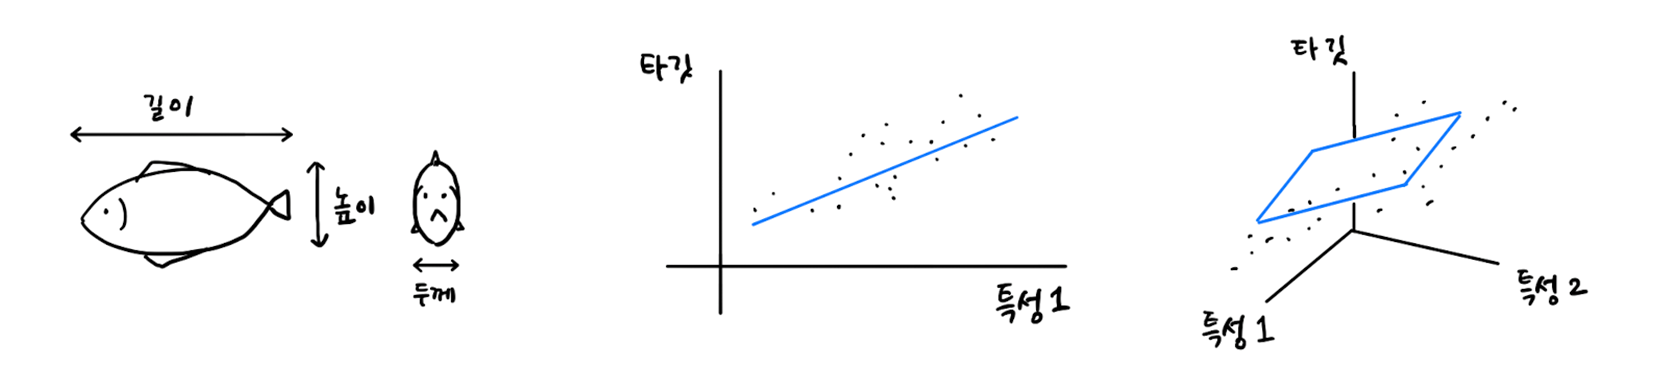

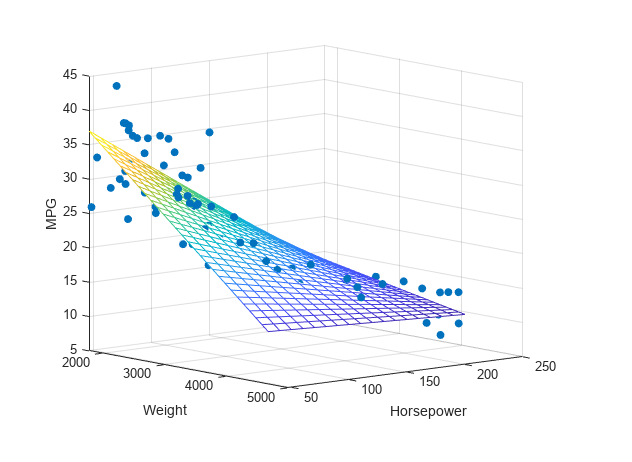

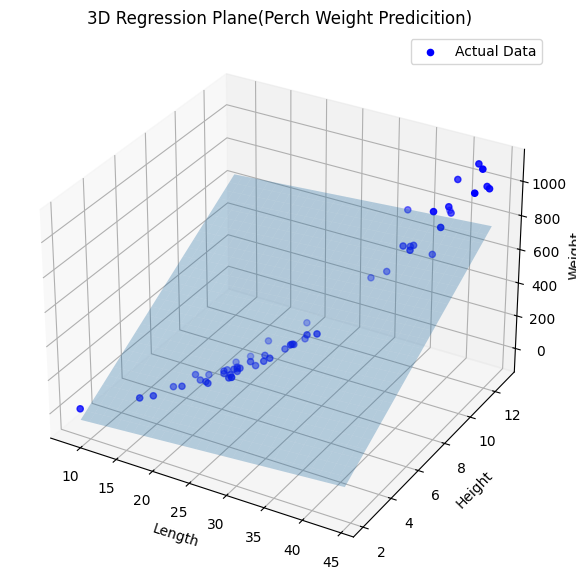

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression

# ----------------------------------
#  1. 입력 데이터
# length, height, width
# 길이,   높이,    너비,
# ----------------------------------
data = np.array([
 [8.4,2.11,1.41],[13.7,3.53,2.0],[15.0,3.82,2.43],[16.2,4.59,2.63],
 [17.4,4.59,2.94],[18.0,5.22,3.32],[18.7,5.2,3.12],[19.0,5.64,3.05],
 [19.6,5.14,3.04],[20.0,5.08,2.77],[21.0,5.69,3.56],[21.0,5.92,3.31],
 [21.0,5.69,3.67],[21.3,6.38,3.53],[22.0,6.11,3.41],[22.0,5.64,3.52],
 [22.0,6.11,3.52],[22.0,5.88,3.52],[22.0,5.52,4.0],[22.5,5.86,3.62],
 [22.5,6.79,3.62],[22.7,5.95,3.63],[23.0,5.22,3.63],[23.5,6.28,3.72],
 [24.0,7.29,3.72],[24.0,6.38,3.82],[24.6,6.73,4.17],[25.0,6.44,3.68],
 [25.6,6.56,4.24],[26.5,7.17,4.14],[27.3,8.32,5.14],[27.5,7.17,4.34],
 [27.5,7.05,4.34],[27.5,7.28,4.57],[28.0,7.82,4.2],[28.7,7.59,4.64],
 [30.0,7.62,4.77],[32.8,10.03,6.02],[34.5,10.26,6.39],[35.0,11.49,7.8],
 [36.5,10.88,6.86],[36.0,10.61,6.74],[37.0,10.84,6.26],[37.0,10.57,6.37],
 [39.0,11.14,7.49],[39.0,11.14,6.0],[39.0,12.43,7.35],[40.0,11.93,7.11],
 [40.0,11.73,7.22],[40.0,12.38,7.46],[40.0,11.14,6.63],[42.0,12.8,6.87],
 [43.0,11.93,7.28],[43.0,12.51,7.42],[43.5,12.6,8.14],[44.0,12.49,7.6]
])

perch_weight = np.array([
 5.9,32.0,40.0,51.5,70.0,100.0,78.0,80.0,85.0,85.0,
 110.0,115.0,125.0,130.0,120.0,120.0,130.0,135.0,110.0,
 130.0,150.0,145.0,150.0,170.0,225.0,145.0,188.0,180.0,
 197.0,218.0,300.0,260.0,265.0,250.0,250.0,300.0,320.0,
 514.0,556.0,840.0,685.0,700.0,700.0,690.0,900.0,650.0,
 820.0,850.0,900.0,1015.0,820.0,1100.0,1000.0,1100.0,
 1000.0,1000.0
])

length = data[:,0]
height = data[:,1]
width = data[:,2]

# ----------------------------------
# 2. 모델 학습 (3개 특성 사용)
# ----------------------------------
X = np.column_stack((length, height, width))
model = LinearRegression()
model.fit(X, perch_weight)

# ----------------------------------
# 3. 회귀 평면 생성 (length, height 기준)
# ----------------------------------
l_range = np.linspace(length.min(), length.max(), 30)
h_range = np.linspace(height.min(), height.max(), 30)
L, H = np.meshgrid(l_range, h_range)

# width는 평균값으로 고장
W = np.full(L.shape, width.mean())

Z = model.predict(np.column_stack((L.ravel(), H.ravel(), W.ravel())))
Z = Z.reshape(L.shape)

# ----------------------------------
# 4. 시각화
# ----------------------------------
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection='3d')

# 실제 데이터
ax.scatter(length, height, perch_weight, color='blue', label='Actual Data')

# 회귀 평면
ax.plot_surface(L, H, Z, alpha=0.3)

ax.set_xlabel('Length')
ax.set_ylabel('Height')
ax.set_zlabel('Weight')
ax.set_title('3D Regression Plane(Perch Weight Predicition)')

plt.legend()
plt.show()
# 점 : 실제 물고기 데이터
# 평면 : 모델이 학습한 예측 공간

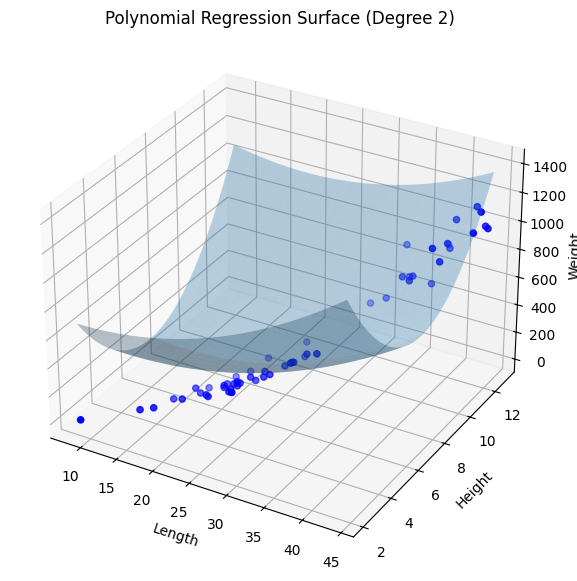

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# -------------------------------
# 1. 데이터 준비
# length, height, width
# 길이    높이    너비
# -------------------------------

data = np.array([
 [8.4,2.11,1.41],[13.7,3.53,2.0],[15.0,3.82,2.43],[16.2,4.59,2.63],
 [17.4,4.59,2.94],[18.0,5.22,3.32],[18.7,5.2,3.12],[19.0,5.64,3.05],
 [19.6,5.14,3.04],[20.0,5.08,2.77],[21.0,5.69,3.56],[21.0,5.92,3.31],
 [21.0,5.69,3.67],[21.3,6.38,3.53],[22.0,6.11,3.41],[22.0,5.64,3.52],
 [22.0,6.11,3.52],[22.0,5.88,3.52],[22.0,5.52,4.0],[22.5,5.86,3.62],
 [22.5,6.79,3.62],[22.7,5.95,3.63],[23.0,5.22,3.63],[23.5,6.28,3.72],
 [24.0,7.29,3.72],[24.0,6.38,3.82],[24.6,6.73,4.17],[25.0,6.44,3.68],
 [25.6,6.56,4.24],[26.5,7.17,4.14],[27.3,8.32,5.14],[27.5,7.17,4.34],
 [27.5,7.05,4.34],[27.5,7.28,4.57],[28.0,7.82,4.2],[28.7,7.59,4.64],
 [30.0,7.62,4.77],[32.8,10.03,6.02],[34.5,10.26,6.39],[35.0,11.49,7.8],
 [36.5,10.88,6.86],[36.0,10.61,6.74],[37.0,10.84,6.26],[37.0,10.57,6.37],
 [39.0,11.14,7.49],[39.0,11.14,6.0],[39.0,12.43,7.35],[40.0,11.93,7.11],
 [40.0,11.73,7.22],[40.0,12.38,7.46],[40.0,11.14,6.63],[42.0,12.8,6.87],
 [43.0,11.93,7.28],[43.0,12.51,7.42],[43.5,12.6,8.14],[44.0,12.49,7.6]
])

perch_weight = np.array([
 5.9,32.0,40.0,51.5,70.0,100.0,78.0,80.0,85.0,85.0,
 110.0,115.0,125.0,130.0,120.0,120.0,130.0,135.0,110.0,
 130.0,150.0,145.0,150.0,170.0,225.0,145.0,188.0,180.0,
 197.0,218.0,300.0,260.0,265.0,250.0,250.0,300.0,320.0,
 514.0,556.0,840.0,685.0,700.0,700.0,690.0,900.0,650.0,
 820.0,850.0,900.0,1015.0,820.0,1100.0,1000.0,1100.0,
 1000.0,1000.0
])

length = data[:,0]
height = data[:,1]
width = data[:,2]

X = np.column_stack((length, height, width))

# -------------------------------
# 2. 다항 특성 변환 (2차)
# -------------------------------
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, perch_weight)

# -------------------------------
# 3. 곡면 생성
# -------------------------------

l_range = np.linspace(length.min(), length.max(), 30)
h_range = np.linspace(height.min(), height.max(), 30)
L, H = np.meshgrid(l_range, h_range)

W = np.full(L.shape, width.mean())

grid = np.column_stack((L.ravel(), H.ravel(), W.ravel()))
grid_poly = poly.transform(grid)

Z = model.predict(grid_poly)
Z = Z.reshape(L.shape)

# -------------------------------
# 4. 시각화
# -------------------------------
fig = plt.figure(figsize = (10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(length, height, perch_weight, color='blue')
ax.plot_surface(L, H, Z, alpha=0.3)

ax.set_xlabel("Length")
ax.set_ylabel("Height")
ax.set_zlabel("Weight")
ax.set_title("Polynomial Regression Surface (Degree 2)")

plt.show()

In [4]:
# 다중회귀 : 여러 개의 특성을 사용한 선형회귀

# 농어의 길이뿐만 아니라 농어의 높이와 두께도 특성에 포함하겠다. (특성 3개)
# 3개의 특성을 제곱하여 추가해야 한다.
# 각 특성을 서로 곱해서 또 다른 특성을 만들 수 있다.
# 이런 특성을 사용해서 새로운 특성을 뽑아내는 것을 특성공학이라고 함

# 데이터 준비 -> 판다스에서 제공하는 데이터 프레임을 사용해 보자.
# 판다스 : 데이터 분석용 라이브러리임 (csv -> 배열로)
# csv 파일은 엑셀에서 텍스트를 뽑아낸 메모장 파일

# pip install pandas 파이참에서 판다스 설치 필수

import pandas as pd # 관례적인 판다스 별칭
# 다중 회귀 : 물고기의 길이와 무게도 있지만 너비도 존재하니
# 더 자세한 회귀가 도출될 거야 (3차원 공간을 형성함)

df = pd.read_csv('https://bit.ly/perch_csv_data') # length, height, width
perch_full = df.to_numpy() # csv 파일을 가져와 넘파일 배열로 변경
print(perch_full) # perch_full 3개의 특성을 가진 배열 값

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [5]:
# length, height, width
# 길이,   높이,   너비

import numpy as np

# 무게 타깃 (정답파일용)
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [6]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_full, perch_weight, random_state=42)
# 훈련 세트와 테스트 세트로 나눔

print(train_input[0], train_target[0])
# 판다스에서 받은 데이터 [length, height, width] weight
#                         [19.6   5.14  3.04] 85.0

[19.6   5.14  3.04] 85.0


In [7]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(
    perch_full, perch_weight, random_state=42)
# 훈련세트와 테스트 세트로 나눔

print(train_input[0], train_target[0])
# 판다스에서 받은 데이터 [length, height, width] weight
#                         [19.6,  5.14    3.04]   85.0

[19.6   5.14  3.04] 85.0
